# Problem 2

## Imports and configuration

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt


if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'Device: CUDA GPU, {torch.cuda.get_device_name(0)}')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print('Device: Apple Silicon MPS')
else:
    device = torch.device('cpu')
    print('Device: CPU')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# display a grid of generated images
def show_images(images, n_row=4, n_col=8, title='Generated samples', figsize=(12, 6)):
    images = images.detach().cpu()
    # normalise to [0, 1]
    images = (images - images.min()) / (images.max() - images.min() + 1e-8)
    
    if images.dim() == 4 and images.shape[1] == 1:
        images = images.squeeze(1) # grayscale: remove channel dim
        
    n = min(n_row * n_col, images.shape[0])
    fig, axes = plt.subplots(n_row, n_col, figsize=figsize)
    for i, ax in enumerate(axes.flat):
        if i < n:
            img = images[i].numpy()
            # (H, W, C) for matplotlib
            if img.shape[0] == 3:
                img = np.transpose(img, (1, 2, 0))
            ax.imshow(img, cmap='gray' if images.dim() == 3 else None)
            ax.axis('off')
            
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

Device: CPU


## DCGAN architecture

In [2]:
IMG_SIZE = 32
NC = 3          # num of channels
NGF = 64        # generator feature map size
NDF = 64        # discriminator feature map size
Z_DIM_DC = 100

def weights_init(m):
    # Initialise conv and batchnorm weights
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class DCGenerator(nn.Module):
    # Produces 3x32x32 images. Architecture: z -> [4x4] -> [8x8] -> [16x16] -> [32x32]
    def __init__(self, z_dim, ngf, nc):
        super().__init__()
        self.main = nn.Sequential(
            # input: (z_dim, 1, 1)
            nn.ConvTranspose2d(z_dim, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # (ngf*4, 4, 4)
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # (ngf*2, 8, 8)
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # (ngf, 16, 16)
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # (nc, 32, 32)
        )

    def forward(self, z):
        return self.main(z)

class DCDiscriminator(nn.Module):
    # Receives 3x32x32 images, outputs scalar in (0,1)
    def __init__(self, nc, ndf):
        super().__init__()
        self.main = nn.Sequential(
            # (nc, 32, 32)
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf, 16, 16)
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*2, 8, 8)
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*4, 4, 4)
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
            # (1, 1, 1)
        )

    def forward(self, x):
        return self.main(x).view(-1, 1)

netG_dc = DCGenerator(Z_DIM_DC, NGF, NC).to(device).apply(weights_init)
netD_dc = DCDiscriminator(NC, NDF).to(device).apply(weights_init)

print('DCGAN Generator params: ', sum(p.numel() for p in netG_dc.parameters()))
print('DCGAN Discriminator params: ', sum(p.numel() for p in netD_dc.parameters()))

DCGAN Generator params:  1068928
DCGAN Discriminator params:  663296


## Data loading and preparation

In [3]:
LR = 2e-4
BATCH = 128

transform_dc = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # normalise to 3 channels
])

# loading CIFAR-10 dataset
cifar_dc = datasets.CIFAR10(root='./data', train=True, transform=transform_dc, download=True)
loader_dc = DataLoader(cifar_dc, batch_size=BATCH, shuffle=True, drop_last=True)

# fixed noise
fixed_noise_dc = torch.randn(32, Z_DIM_DC, 1, 1, device=device)

opt_D_dc = optim.Adam(netD_dc.parameters(), lr=LR, betas=(0.5, 0.999))
opt_G_dc = optim.Adam(netG_dc.parameters(), lr=LR, betas=(0.5, 0.999))

C:\Users\zawer\documents\applied_math\sem1\machine_learning\assingments\ml_assingments_venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## Main learning loop

In [4]:
EPOCHS_DC = 15
bce_dc = nn.BCELoss()

hist_D_dc, hist_G_dc = [], []

for epoch in range(EPOCHS_DC):
    loss_D_sum = 0.0
    loss_G_sum = 0.0
    
    for real, _ in loader_dc:
        m = real.size(0)
        real = real.to(device)
        
        ones = torch.ones(m, 1, device=device)
        zeros = torch.zeros(m, 1, device=device)
        
        # ---- Update D ----
        z = torch.randn(m, Z_DIM_DC, 1, 1, device=device)
        fake = netG_dc(z).detach()
        
        loss_D = bce_dc(netD_dc(real), ones) + bce_dc(netD_dc(fake), zeros)
        
        opt_D_dc.zero_grad()
        loss_D.backward()
        opt_D_dc.step()
        
        # ---- Update G ----
        z = torch.randn(m, Z_DIM_DC, 1, 1, device=device)
        fake = netG_dc(z)
        
        loss_G = bce_dc(netD_dc(fake), ones)
        
        opt_G_dc.zero_grad()
        loss_G.backward()
        opt_G_dc.step()
        
        loss_D_sum += loss_D.item()
        loss_G_sum += loss_G.item()
        
    avg_D = loss_D_sum / len(loader_dc)
    avg_G = loss_G_sum / len(loader_dc)
    
    hist_D_dc.append(avg_D)
    hist_G_dc.append(avg_G)
    
    # logs in terminal
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1:3d}/{EPOCHS_DC}] loss_D: {avg_D:.4f} loss_G: {avg_G:.4f}')

print('DCGAN training complete.')

Epoch [  1/15] loss_D: 0.3503 loss_G: 5.4179
Epoch [  5/15] loss_D: 0.5206 loss_G: 2.9007
Epoch [ 10/15] loss_D: 0.6938 loss_G: 2.2509
Epoch [ 15/15] loss_D: 0.6919 loss_G: 2.0775
DCGAN training complete.


## Visualization

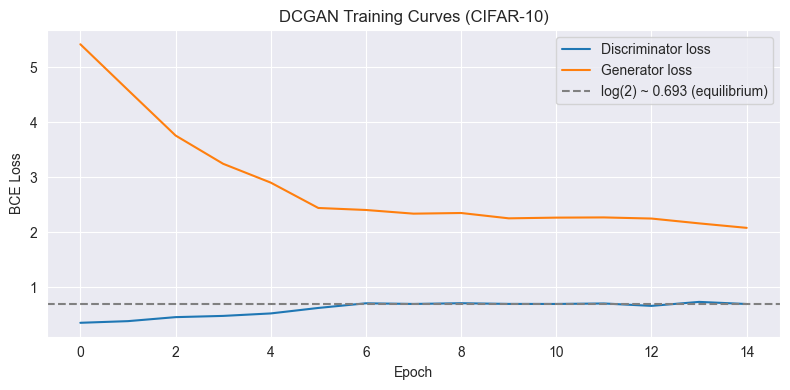

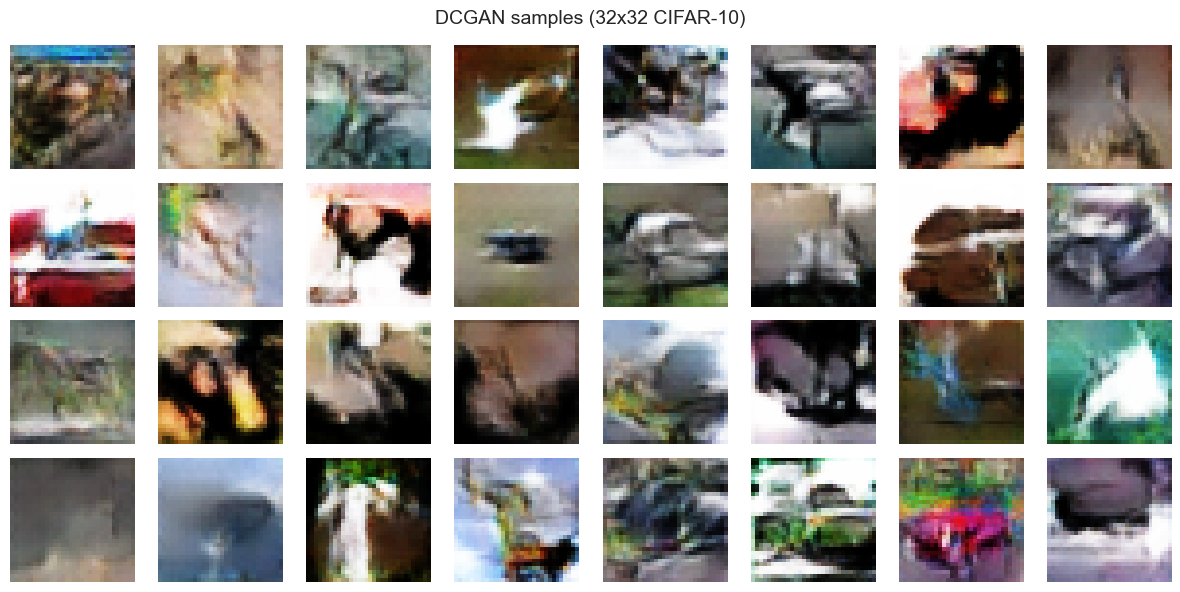

In [5]:
# visualization of losses
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hist_D_dc, label='Discriminator loss')
ax.plot(hist_G_dc, label='Generator loss')
ax.axhline(y=np.log(2), color='gray', linestyle='--', label='log(2) ~ 0.693 (equilibrium)')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('DCGAN Training Curves (CIFAR-10)')
ax.legend()
plt.tight_layout()
plt.show()

# visulization of generated images
netG_dc.eval()
with torch.no_grad():
    dc_samples = netG_dc(fixed_noise_dc)

show_images(dc_samples, n_row=4, n_col=8, title='DCGAN samples (32x32 CIFAR-10)')

## FID-like

In [6]:
from scipy import linalg


def compute_fid_like(real_loader, gen_model, z_dim, n_samples=2000, device='cpu'):
    real_feats, fake_feats = [], []
    gen_model.eval()
    
    with torch.no_grad():
        # collecting pixels of real images
        for batch, _ in real_loader:
            real_feats.append(batch.view(batch.size(0), -1).numpy())
            if len(np.concatenate(real_feats)) >= n_samples:
                break
                
        # collecting pixels of generated data
        collected = 0
        while collected < n_samples:
            bs = min(256, n_samples - collected)
            z = torch.randn(bs, z_dim, 1, 1, device=device)
            # CIFAR vector 3x32x32 = 3072
            fake = gen_model(z).cpu().view(bs, -1).numpy()
            fake_feats.append(fake)
            collected += bs
            
    real_feats = np.concatenate(real_feats)[:n_samples]
    fake_feats = np.concatenate(fake_feats)[:n_samples]
    
    # statistics
    mu_r, mu_g = real_feats.mean(axis=0), fake_feats.mean(axis=0)
    sigma_r = np.cov(real_feats, rowvar=False)
    sigma_g = np.cov(fake_feats, rowvar=False)
    
    # regularization
    eps = 1e-6
    sigma_r += eps * np.eye(sigma_r.shape[0])
    sigma_g += eps * np.eye(sigma_g.shape[0])
    
    cov_mean = linalg.sqrtm(sigma_r @ sigma_g)
    if np.iscomplexobj(cov_mean):
        cov_mean = cov_mean.real
        
    fid = np.sum((mu_r - mu_g) ** 2) + np.trace(sigma_r + sigma_g - 2.0 * cov_mean)
    return float(fid)

In [7]:
print('Computing FID-like score on pixel features...')

transform_raw = transforms.Compose([
    transforms.Resize(IMG_SIZE), 
    transforms.ToTensor()
])

# test data for CIFAR-10
cifar_raw = datasets.CIFAR10(root='./data', train=False, transform=transform_raw, download=True)
loader_raw = DataLoader(cifar_raw, batch_size=256, shuffle=False)

netG_dc_cpu = netG_dc.to('cpu')

fid_score = compute_fid_like(loader_raw, netG_dc_cpu, Z_DIM_DC, n_samples=2000, device='cpu')

netG_dc.to(device)

print(f'Pixel-space FID-like score: {fid_score:.2f}')
print('(Lower is better; 0 = identical distributions)')

Computing FID-like score on pixel features...
Pixel-space FID-like score: 1310.77
(Lower is better; 0 = identical distributions)


## FID

In [8]:
import torch.nn.functional as F
from torchvision.models import inception_v3, Inception_V3_Weights
from scipy import linalg
from tqdm import tqdm

inception_model = inception_v3(weights=Inception_V3_Weights.DEFAULT, transform_input=True)

inception_model.fc = nn.Identity() 

inception_model = inception_model.to(device)
inception_model.eval()

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [9]:
def get_inception_features(images, model):
    # resizing from 32x32 to 299x299
    images_resized = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)
    
    with torch.no_grad():
        features = model(images_resized)
        
    return features.cpu().numpy()

In [10]:
def compute_full_fid(real_loader, gen_model, inception, z_dim, n_samples=10000, device='cpu'):
    real_feats, fake_feats = [], []
    gen_model.eval()
    
    print(f"Calculating full FID for {n_samples} samples...")
    
    with torch.no_grad():
        # collecting pixels for real images
        collected_real = 0
        print("Extracting features from real images...")
        for batch, _ in tqdm(real_loader, desc="Real images"):
            batch = batch.to(device)
            feats = get_inception_features(batch, inception)
            real_feats.append(feats)
            collected_real += batch.size(0)
            if collected_real >= n_samples:
                break
                
        # collecting pixels for generated images
        collected_fake = 0
        batch_size_fid = 64
        
        print("Generating and extracting features from fake images...")
        pbar_fake = tqdm(total=n_samples, desc="Fake images")
        
        while collected_fake < n_samples:
            curr_bs = min(batch_size_fid, n_samples - collected_fake)
            z = torch.randn(curr_bs, z_dim, 1, 1, device=device)
            
            fake_images = gen_model(z)
            # scaling
            fake_images_01 = (fake_images + 1.0) / 2.0
            
            feats = get_inception_features(fake_images_01, inception)
            fake_feats.append(feats)
            collected_fake += curr_bs
            
            pbar_fake.update(curr_bs)
        
        pbar_fake.close()

    real_feats = np.concatenate(real_feats, axis=0)[:n_samples]
    fake_feats = np.concatenate(fake_feats, axis=0)[:n_samples]
    
    print("Calculating covariance matrices")
    
    # statistics
    mu_r, mu_g = real_feats.mean(axis=0), fake_feats.mean(axis=0)
    sigma_r = np.cov(real_feats, rowvar=False)
    sigma_g = np.cov(fake_feats, rowvar=False)
    
    eps = 1e-6
    sigma_r += eps * np.eye(sigma_r.shape[0])
    sigma_g += eps * np.eye(sigma_g.shape[0])
    
    cov_mean = linalg.sqrtm(sigma_r @ sigma_g)
    if np.iscomplexobj(cov_mean):
        cov_mean = cov_mean.real
        
    fid = np.sum((mu_r - mu_g) ** 2) + np.trace(sigma_r + sigma_g - 2.0 * cov_mean)
    return float(fid)

In [11]:
# test data
transform_clean = transforms.Compose([
    transforms.Resize(32), 
    transforms.ToTensor()
])

cifar_clean = datasets.CIFAR10(root='./data', train=False, transform=transform_clean, download=True)
loader_clean = DataLoader(cifar_clean, batch_size=32, shuffle=False)

final_fid = compute_full_fid(
    real_loader=loader_clean, 
    gen_model=netG_dc, 
    inception=inception_model, 
    z_dim=Z_DIM_DC, 
    n_samples=10000,
    device=device
)

print(f'FID: {final_fid:.2f}')

Calculating full FID for 10000 samples...
Extracting features from real images...


Real images: 100%|█████████▉| 312/313 [16:59<00:03,  3.27s/it]


Generating and extracting features from fake images...


Fake images: 100%|██████████| 10000/10000 [17:21<00:00,  9.60it/s]


Calculating covariance matrices
FID: 29.83


# Problem 1

In [67]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE

### The SimpleVAE Architecture

The class implements the core structure of a Variational Autoencoder. 

The model takes a flattened input vector $x$ and passes it through an encoder to find a probability distribution in the latent space, mathematically denoted as $q(z|x,\phi)$. 

Because we model this posterior distribution as a multivariate Gaussian, the encoder specifically outputs two parameter vectors: the means ($\mu$) and the log-variances ($\log(\sigma^2)$).

Next, we use the reparameterization trick to smoothly sample a latent vector $z$ from this learned distribution. Finally, we pass this sampled vector $z$ into the decoder. 

The decoder transforms the compressed latent representation back into the original input dimensions, producing the parameters for the likelihood distribution $p(x|z,\theta)$, which serves as our final reconstructed data $\hat{x}$.

In [68]:
# VAE model
class SimpleVAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(SimpleVAE, self).__init__()
        
        # Encoder: Single sequential block for the shared hidden layer
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )
        
        # Latent space parameters
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        
        # Decoder: Maps latent vector back to the original image dimensions
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid() # Squashes output to [0, 1] for pixel intensities
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        """reparametrize from Gaussian posterior of z with reparametrization"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
     #This applies the first linear layer of the decoder, followed by a ReLU and then maps the hidden state to a vector of means and variances that parametrizes q(z|x,ϕ).
    #The decoder depends on the likelihood we chose
    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)  # get posterior parameters
        z = self.reparameterize(mu, logvar) # sample with reparametrization
        recon_x = self.decode(z) # get likelihood parameters
        return recon_x, mu, logvar

### The VAE Loss Function

VAE loss - minimize the negative Evidence Lower Bound (ELBO): $L = \text{Reconstruction} + D_{KL}$.

**1. Reconstruction Loss**
This measures how accurately the decoder rebuilds the original input $x$.
$$\text{BCE} = - \sum_{i} \left( x_i \log(\hat{x}_i) + (1 - x_i) \log(1 - \hat{x}_i) \right)$$

**2. KL Divergence**
This forces the learnt latent distribution to match a standard normal distribution $\mathcal{N}(0, 1)$.
$$D_{KL} = -\frac{1}{2} \sum_{j=1}^{J} \left( 1 + \log(\sigma_j^2) - \mu_j^2 - \sigma_j^2 \right)$$
The network predicts `logvar` ($\log(\sigma^2)$) instead of variance to ensure numerical stability.

In [69]:
# Loss Function
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="sum")
    kld_loss = -0.5 * torch.sum(1 + logvar - mu**2 - logvar.exp())
    return recon_loss + kld_loss

In [70]:
# Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
epochs = 10
learning_rate = 1e-3


# Load Fashion-MNIST
transform = transforms.ToTensor()
train_dataset = datasets.FashionMNIST(root='/tmp/data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='/tmp/data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False) # t-SNE

In [71]:
model = SimpleVAE(input_dim=784, hidden_dim=400, latent_dim=20).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
epoch_loss = []
for epoch in range(1, epochs+1):
    model.train()
    train_loss = 0
    for data, _ in train_loader:
        # Flatten the 28x28 images into 784-dimensional vectors
        data = data.view(-1, 784).to(device)
        
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = vae_loss(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
    loss_at_point = train_loss / len(train_loader.dataset)
    epoch_loss.append(loss_at_point)
    print(f"Epoch {epoch}/{epochs}, Loss: {train_loss / len(train_loader.dataset):.4f}")

Epoch 1/10, Loss: 286.8749
Epoch 2/10, Loss: 256.4404
Epoch 3/10, Loss: 250.5262
Epoch 4/10, Loss: 247.6558
Epoch 5/10, Loss: 246.0400
Epoch 6/10, Loss: 244.8695
Epoch 7/10, Loss: 244.0029
Epoch 8/10, Loss: 243.3521
Epoch 9/10, Loss: 242.8346
Epoch 10/10, Loss: 242.3629


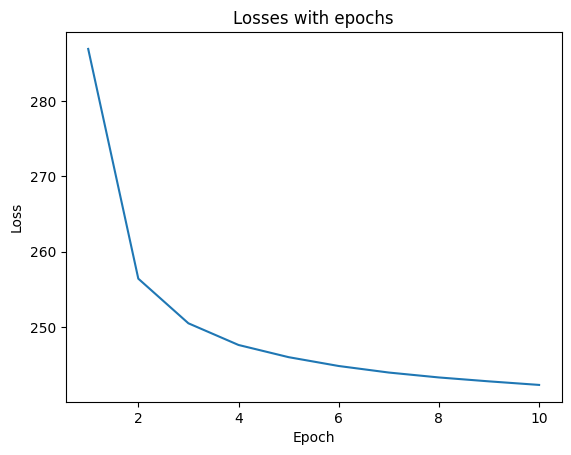

In [72]:
plt.plot(range(1, epochs+1),epoch_loss)
plt.title('Losses with epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## T-distributed Stochastic Neighbor Embedding

t-SNE is a tool to visualize high-dimensional data. 

It converts similarities between data points to joint probabilities and tries to minimize the Kullback-Leibler divergence between the joint probabilities of the low-dimensional embedding and the high-dimensional data. 

t-SNE has a cost function that is not convex, i.e. with different initializations we can get different results.

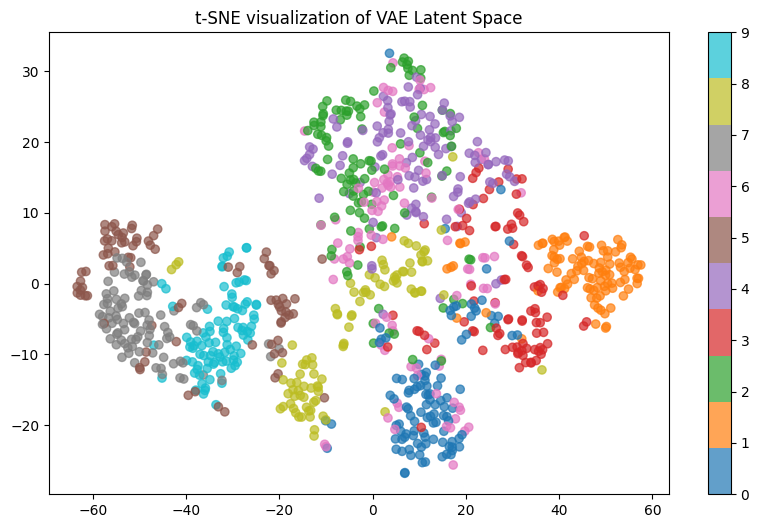

In [73]:
# Visualization of latent space - t-SNE
model.eval()

# Grab one large batch of test data
test_data, test_labels = next(iter(test_loader))
test_data = test_data.view(-1, 784).to(device)

with torch.no_grad():
    mu, _ = model.encode(test_data)
    mu = mu.cpu().numpy()

tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(mu)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=test_labels.numpy(), cmap='tab10', alpha=0.7)
plt.colorbar(scatter, ticks=range(10))
plt.title("t-SNE visualization of VAE Latent Space")
plt.show()

0 T-shirt/top
1 Trouser
2 Pullover
3 Dress
4 Coat
5 Sandal
6 Shirt
7 Sneaker
8 Bag
9 Ankle boot

tensor([[-0.1518,  3.5838, -0.7049,  0.8376,  0.8769,  0.7552,  0.4582,  0.1128,
          1.7485,  2.7327,  1.7785, -0.8201, -0.6062, -0.5293,  1.3022, -0.9941,
          0.4506, -2.2022,  1.0767, -0.6161],
        [-1.0857,  0.0678,  1.2322,  0.5661, -0.4278,  1.5661, -0.5799,  0.9612,
         -0.5605,  0.8954, -0.5071,  2.2922, -1.3856, -0.5673, -2.0831, -1.2576,
         -0.2562, -0.9709,  1.3368,  0.4100],
        [-0.9050, -0.0547, -0.3553,  0.1501, -1.1933,  0.7413, -0.5768, -0.3196,
          1.5362,  0.0738, -1.6107,  0.3178,  0.0514,  0.5825, -1.4846, -1.5341,
          0.1424,  0.6250, -0.1658,  0.8077],
        [ 0.6526, -1.5903, -0.1423, -0.0716, -0.9895, -1.6893,  0.6114, -0.3531,
          1.4495, -0.9191, -1.0994, -0.2096, -1.3256,  1.1055, -0.3480, -2.5600,
         -0.5556, -2.0803, -1.4023, -0.0183],
        [ 0.3617, -0.1819, -0.8228,  0.5781, -1.6359,  1.1377,  1.3293, -0.8203,
         -0.1660,  1.5222, -1.7518,  0.8899, -1.9625, -0.9355,  1.0503, -0.1198,
      

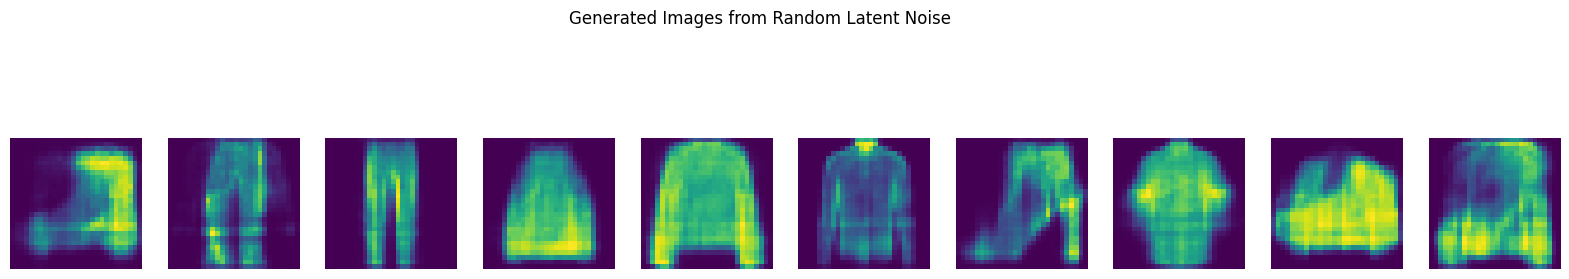

In [74]:
# Generate new sample from latent distribution
with torch.no_grad():
    # Sample 10 random vectors from standard normal distribution
    z_random = torch.randn(10, 20).to(device)
    print(z_random)
    generated_images = model.decode(z_random).cpu()

fig, axes = plt.subplots(1, 10, figsize=(20, 4))
for i, ax in enumerate(axes):
    ax.imshow(generated_images[i].view(28, 28))
    ax.axis('off')
plt.suptitle("Generated Images from Random Latent Noise")
plt.show()

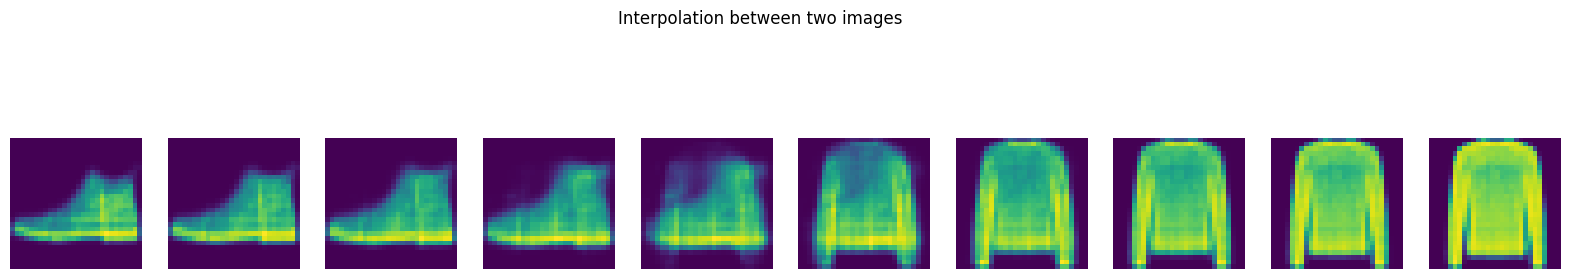

In [75]:
# Latent space interpolation between images
with torch.no_grad():
    # two real images from the dataset
    img1, img2 = test_dataset[0][0], test_dataset[1][0]
    img1_flat, img2_flat = img1.view(1, 784).to(device), img2.view(1, 784).to(device)
    
    # Get their latent representations (mu)
    mu1, _ = model.encode(img1_flat)
    mu2, _ = model.encode(img2_flat)
    
    # Create 10 steps between mu1 and mu2
    steps = 10
    alphas = torch.linspace(0, 1, steps).view(-1, 1).to(device)
    z_interp = mu1 * (1 - alphas) + mu2 * alphas
    
    # Decode the interpolated latent vectors
    interp_images = model.decode(z_interp).cpu()

fig, axes = plt.subplots(1, steps, figsize=(20, 4))
for i, ax in enumerate(axes):
    ax.imshow(interp_images[i].view(28, 28))
    ax.axis('off')
plt.suptitle("Interpolation between two images")
plt.show()

# Problem 3

In [76]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

In the image VAE, a Sigmoid layer was used at the end of the decoder because image pixels are normalized between 0 and 1.

 However, the credit card data is standardized, meaning it contains negative numbers. 
 
 If the Sigmoid layer was kept, the decoder could never output anything below 0, completely ruining the reconstruction of the tabular data.

In [77]:
# VAE Model for Tabular Data
class TabularVAE(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, latent_dim=16):
        super(TabularVAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        
        # No Sigmoid at the end because Standard Scaled data can be negative
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

Using MSE -> we are mathematically assuming that the decoder's output follows a Gaussian distribution

In [78]:
def vae_loss_mse(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction="sum")
    kld_loss = -0.5 * torch.sum(1 + logvar - mu**2 - logvar.exp())
    return recon_loss + kld_loss

In [79]:
# Data Preparation
data = fetch_openml('creditcard', version=1, as_frame=False, data_home='/tmp/data', parser='auto')

X = data.data
y = np.array(data.target).astype(float) # 0 for normal, 1 for fraud

# Split data into Normal (0) and Fraud (1)
normal_mask = (y == 0)
fraud_mask = (y == 1)

X_normal = X[normal_mask]
y_normal = y[normal_mask]
X_fraud = X[fraud_mask]
y_fraud = y[fraud_mask]

# Train only on 80% of normal data
X_train_norm, X_test_norm, _, y_test_norm = train_test_split(
    X_normal, y_normal, test_size=0.2, random_state=42
)

# Test: 20% of normal data + ALL fraud data
X_test = np.vstack([X_test_norm, X_fraud])
y_test = np.hstack([y_test_norm, y_fraud])

# Standardize features (fit ONLY on train normal data)
scaler = StandardScaler()
X_train_norm_scaled = scaler.fit_transform(X_train_norm)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
train_tensor = torch.tensor(X_train_norm_scaled, dtype=torch.float32)
test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
test_labels = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(train_tensor, torch.zeros(len(train_tensor))), batch_size=256, shuffle=True)
test_loader = DataLoader(TensorDataset(test_tensor, test_labels), batch_size=256, shuffle=False)

In [80]:
# Train the VAE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X.shape[1]
learning_rate = 1e-3
epochs = 15

model = TabularVAE(input_dim=input_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

model.train()
epoch_loss = []
for epoch in range(1, epochs+1):
    train_loss = 0
    for data, _ in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = vae_loss_mse(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
    loss_at_point = train_loss / len(train_loader.dataset)
    epoch_loss.append(loss_at_point)
    print(f"Epoch {epoch}/{epochs}, Loss: {train_loss / len(train_loader.dataset):.4f}")

Epoch 1/15, Loss: 24.2500
Epoch 2/15, Loss: 19.5028
Epoch 3/15, Loss: 18.2671
Epoch 4/15, Loss: 17.6223
Epoch 5/15, Loss: 17.2376
Epoch 6/15, Loss: 16.9155
Epoch 7/15, Loss: 16.5958
Epoch 8/15, Loss: 16.3644
Epoch 9/15, Loss: 16.1943
Epoch 10/15, Loss: 16.0582
Epoch 11/15, Loss: 15.9477
Epoch 12/15, Loss: 15.8689
Epoch 13/15, Loss: 15.7847
Epoch 14/15, Loss: 15.7319
Epoch 15/15, Loss: 15.6747


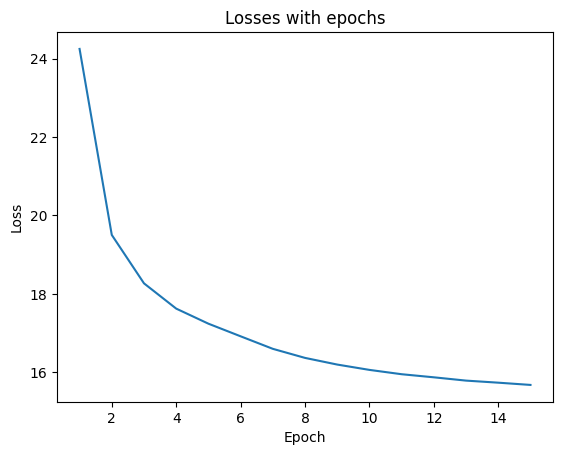

In [81]:
plt.plot(range(1, epochs+1),epoch_loss)
plt.title('Losses with epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [82]:
# Generate VAE Anomaly Scores
model.eval()
vae_scores = []
with torch.no_grad():
    for data, _ in test_loader:
        data = data.to(device)
        recon_batch, _, _ = model(data)
        # Calculate MSE per sample as the anomaly score
        mse_per_sample = torch.mean((data - recon_batch) ** 2, dim=1)
        vae_scores.extend(mse_per_sample.cpu().numpy())
vae_scores = np.array(vae_scores)

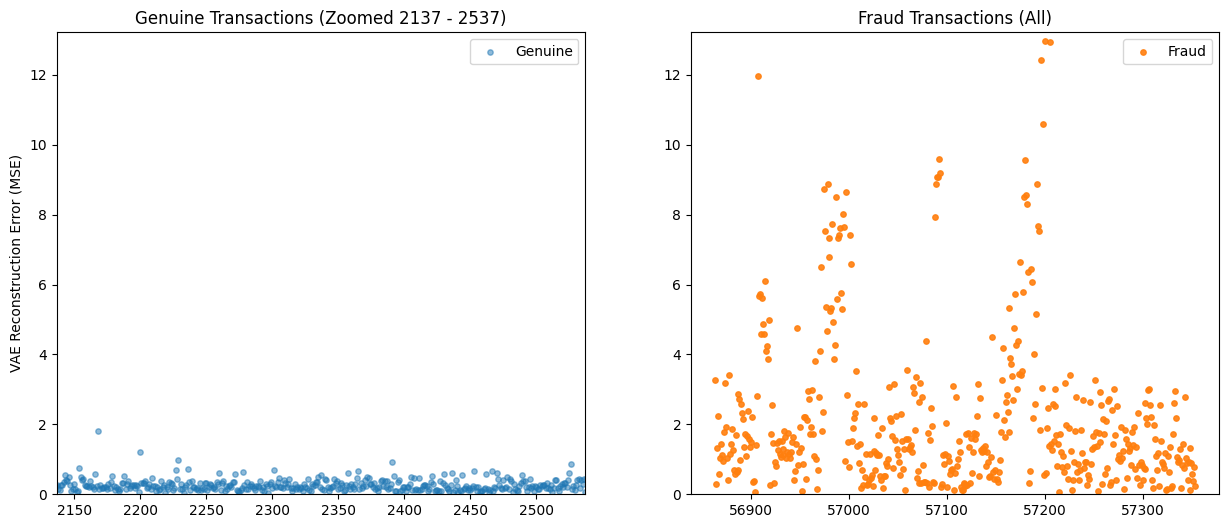

In [83]:
# Ensure y_test is a numpy array for boolean masking
y_test_np = np.array(y_test)
indices = np.arange(len(vae_scores))

normal_mask = (y_test_np == 0)
fraud_mask = (y_test_np == 1)

genuine_in_range_mask = normal_mask & (indices >= 2137) & (indices <= 2537)
max_genuine = vae_scores[genuine_in_range_mask].max() if genuine_in_range_mask.any() else 0


max_fraud = vae_scores[fraud_mask].max() if fraud_mask.any() else 0

max_y = max(max_genuine, max_fraud) * 1.02 

# Create a figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.scatter(indices[normal_mask], vae_scores[normal_mask], 
            color='tab:blue', label='Genuine', alpha=0.5, s=15)
ax1.set_xlim(2137, 2537)
ax1.set_ylim(0, max_y)
ax1.set_ylabel('VAE Reconstruction Error (MSE)')
ax1.set_title('Genuine Transactions (Zoomed 2137 - 2537)')
ax1.legend()

ax2.scatter(indices[fraud_mask], vae_scores[fraud_mask], 
            color='tab:orange', label='Fraud', alpha=0.9, s=15)
ax2.set_ylim(0, max_y)
ax2.set_title('Fraud Transactions (All)')
ax2.legend()

plt.show()

In [84]:
# Traditional Baselines

# Train on normal data (we use a subset to speed up training, IF scales decently well though)
iso_forest = IsolationForest(n_estimators=100, random_state=42)
iso_forest.fit(X_train_norm_scaled)
# IF returns negative scores for anomalies, so we invert them (* -1) so higher = anomaly
if_scores = -iso_forest.score_samples(X_test_scaled)

# OCSVM scales poorly (O(n^2)), so we train on a random subset of 50,000 normal samples
subset_idx = np.random.choice(len(X_train_norm_scaled), 50000, replace=False)
oc_svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.01)
oc_svm.fit(X_train_norm_scaled)
# OCSVM returns negative scores for anomalies, invert them (* -1)
svm_scores = -oc_svm.score_samples(X_test_scaled)

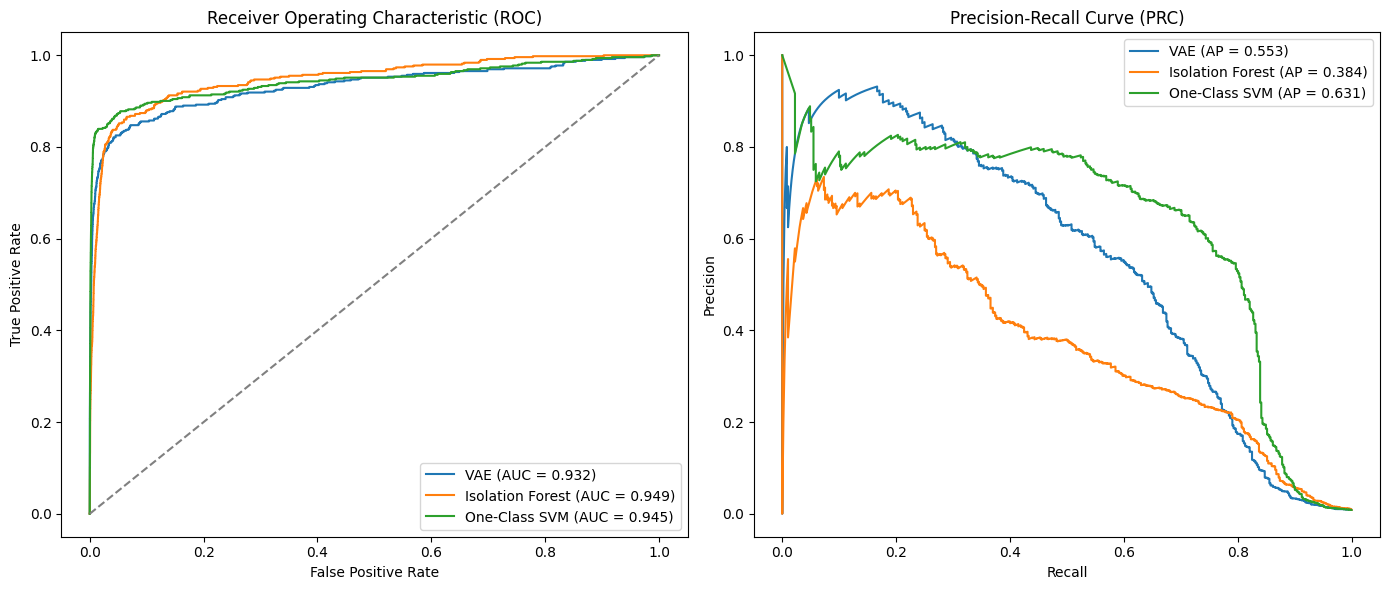

In [85]:
# ROC-AUC & PR-AUC
results = {
    "VAE": vae_scores,
    "Isolation Forest": if_scores,
    "One-Class SVM": svm_scores
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for name, scores in results.items():
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')
    
    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, scores)
    pr_auc = average_precision_score(y_test, scores)
    ax2.plot(recall, precision, label=f'{name} (AP = {pr_auc:.3f})')

# Formatting plots
ax1.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax1.set_title('Receiver Operating Characteristic (ROC)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()

ax2.set_title('Precision-Recall Curve (PRC)')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend()

plt.tight_layout()
plt.show()

Given the class imbalance ratio, we recommend measuring the accuracy using the Area Under the Precision-Recall Curve (AUPRC).

 Confusion matrix accuracy is not meaningful for unbalanced classification.

# ROC-AUC
 The ROC curve plots this trade-off:
Y-axis: True Positive Rate (Recall) — How much of the actual fraud are you catching?
X-axis: False Positive Rate — How many innocent transactions are you falsely flagging?

# PRC

 Looking at the blue line, your VAE can successfully catch about 50% of all fraud (Recall = 0.5) while ensuring that roughly 85% to 90% of its alerts are actual fraud (Precision)